N7023-SEMCD-14_UdayKiranMudu

### Step 1: Install PySpark

In [ ]:
# Install pyspark using Pip
!pip install pyspark

### Step 2: Create a Spark Session

In [ ]:
from pyspark.sql import SparkSession

spark = SparkSession \
    .builder \
    .appName("Python Spark SQL basic example") \
    .config("spark.some.config.option", "some-value") \
    .getOrCreate()

### Step 3: Mount Google Drive

You need to upload your `diabetes.csv` file to your Google Drive. For example, you can create a folder named `Colab Notebooks` and place the `diabetes.csv` file inside it. Then, you can mount your Google Drive as shown below.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


### Step 4: Load the Data File (`titanic_synthetic_data.csv`)

Make sure the path to `titanic_synthetic_data.csv` is correct based on where you uploaded it in your Google Drive.

In [ ]:
# Load the diabetes.csv file into a Spark DataFrame
dataset = spark.read.csv('/content/titanic_synthetic_data.csv', inferSchema=True, header=True)

### Step 5: Check the Columns in the Dataset

In [ ]:
# What are the columns in this dataset
dataset.columns

['Pclass',
 'Age',
 'SibSp',
 'Parch',
 'Fare',
 'Sex',
 'Survived',
 'Embarked_Q',
 'Embarked_S']

### Step 6: Explore Data Distribution using `describe()`

In [ ]:
dataset.describe().select("Summary", "Pclass", "Age", "SibSp", "Parch", "Fare").show()

+-------+------------------+------------------+------------------+------------------+------------------+
|Summary|            Pclass|               Age|             SibSp|             Parch|              Fare|
+-------+------------------+------------------+------------------+------------------+------------------+
|  count|           1000000|           1000000|           1000000|           1000000|           1000000|
|   mean|          1.999411|         39.517847|          4.500906|          4.497493| 254.9829083944402|
| stddev|0.8168263709530482|23.092708389398037|2.8714427426552285|2.8728101169393594|141.53963219142216|
|    min|                 1|                 0|                 0|                 0|10.000191449724019|
|    max|                 3|                79|                 9|                 9| 499.9999338139367|
+-------+------------------+------------------+------------------+------------------+------------------+



### Step 7: Check for Null, None, NaN & Empty Blank Values (Initial)

In [ ]:
from pyspark.sql.functions import col, isnan, when, count
dataset.select([count(when(isnan(c) | col(c).isNull(), c)).alias(c) for c in dataset.columns]).show()

+------+---+-----+-----+----+---+--------+----------+----------+
|Pclass|Age|SibSp|Parch|Fare|Sex|Survived|Embarked_Q|Embarked_S|
+------+---+-----+-----+----+---+--------+----------+----------+
|     0|  0|    0|    0|   0|  0|       0|         0|         0|
+------+---+-----+-----+----+---+--------+----------+----------+



### Step 8: Replace Zero Values with NaN (Data Cleaning)

Some columns contain '0' which are actually missing values (e.g., BloodPressure cannot be 0). These will be replaced with `np.nan` for proper imputation.

In [ ]:
import numpy as np
from pyspark.sql.functions import when

# The following lines are commented out as they are specific to the diabetes dataset
# and the target columns (Glucose, BloodPressure, etc.) do not exist in the Titanic dataset.
# If the Titanic dataset has '0' values that represent missing data in other columns,
# this logic would need to be re-evaluated for those specific columns.
# dataset = dataset.withColumn("Glucose", when(dataset.Glucose == 0, np.nan).otherwise(dataset.Glucose))
# dataset = dataset.withColumn("BloodPressure", when(dataset.BloodPressure == 0, np.nan).otherwise(dataset.BloodPressure))
# dataset = dataset.withColumn("SkinThickness", when(dataset.SkinThickness == 0, np.nan).otherwise(dataset.SkinThickness))
# dataset = dataset.withColumn("BMI", when(dataset.BMI == 0, np.nan).otherwise(dataset.BMI))
# dataset = dataset.withColumn("Insulin", when(dataset.Insulin == 0, np.nan).otherwise(dataset.Insulin))

# Displaying a sample of the dataset after potential (or skipped) cleaning
dataset.show(5)

+------+---+-----+-----+------------------+---+--------+----------+----------+
|Pclass|Age|SibSp|Parch|              Fare|Sex|Survived|Embarked_Q|Embarked_S|
+------+---+-----+-----+------------------+---+--------+----------+----------+
|     3| 42|    6|    7|397.00178367782024|  0|       0|         0|         1|
|     1| 52|    6|    7|302.12770032784186|  0|       0|         1|         0|
|     3| 25|    3|    8| 427.1058765283985|  1|       1|         1|         0|
|     3| 32|    9|    7| 326.8049924602327|  1|       0|         0|         0|
|     1| 40|    0|    5|17.718838497771657|  0|       0|         0|         0|
+------+---+-----+-----+------------------+---+--------+----------+----------+
only showing top 5 rows


### Step 9: Check for NaN Values Again (After Replacement)

In [ ]:
from pyspark.sql.functions import col, isnan, when, count
dataset.select([count(when(isnan(c), c)).alias(c) for c in dataset.columns]).show()

+------+---+-----+-----+----+---+--------+----------+----------+
|Pclass|Age|SibSp|Parch|Fare|Sex|Survived|Embarked_Q|Embarked_S|
+------+---+-----+-----+----+---+--------+----------+----------+
|     0|  0|    0|    0|   0|  0|       0|         0|         0|
+------+---+-----+-----+----+---+--------+----------+----------+



### Step 10: Impute Missing Values

Using `Imputer` to fill `NaN` values with the mean or median of their respective columns.

In [ ]:
from pyspark.ml.feature import Imputer

# The previous check for NaN values (cell f2199ca9) showed no missing values
# in the titanic_synthetic_data.csv dataset. Therefore, the imputation step
# is not necessary for this dataset and is commented out.
# imputer = Imputer(inputCols=["Glucose", "BloodPressure", "SkinThickness", "BMI", "Insulin"], outputCols=["Glucose", "BloodPressure", "SkinThickness", "BMI", "Insulin"])
# model = imputer.fit(dataset)
# dataset = model.transform(dataset)

dataset.show(5)

+------+---+-----+-----+------------------+---+--------+----------+----------+
|Pclass|Age|SibSp|Parch|              Fare|Sex|Survived|Embarked_Q|Embarked_S|
+------+---+-----+-----+------------------+---+--------+----------+----------+
|     3| 42|    6|    7|397.00178367782024|  0|       0|         0|         1|
|     1| 52|    6|    7|302.12770032784186|  0|       0|         1|         0|
|     3| 25|    3|    8| 427.1058765283985|  1|       1|         1|         0|
|     3| 32|    9|    7| 326.8049924602327|  1|       0|         0|         0|
|     1| 40|    0|    5|17.718838497771657|  0|       0|         0|         0|
+------+---+-----+-----+------------------+---+--------+----------+----------+
only showing top 5 rows


### Step 11: Combine All Features into a Single Vector

In [ ]:
from pyspark.ml.feature import VectorAssembler

# Define the feature columns for the Titanic dataset, excluding the 'Survived' column (which is the label)
feature_cols = [col for col in dataset.columns if col != 'Survived']

assembler = VectorAssembler(inputCols=feature_cols, outputCol="features")
# Now let us use the transform method to transform our dataset
dataset = assembler.transform(dataset)
dataset.select("features", "Survived").show(5, truncate=False)

+-------------------------------------------------+--------+
|features                                         |Survived|
+-------------------------------------------------+--------+
|[3.0,42.0,6.0,7.0,397.00178367782024,0.0,0.0,1.0]|0       |
|[1.0,52.0,6.0,7.0,302.12770032784186,0.0,1.0,0.0]|0       |
|[3.0,25.0,3.0,8.0,427.1058765283985,1.0,1.0,0.0] |1       |
|[3.0,32.0,9.0,7.0,326.8049924602327,1.0,0.0,0.0] |0       |
|(8,[0,1,3,4],[1.0,40.0,5.0,17.718838497771657])  |0       |
+-------------------------------------------------+--------+
only showing top 5 rows


### Step 12: Standardize Features using StandardScaler

In [ ]:
from pyspark.ml.feature import StandardScaler
standardscaler = StandardScaler().setInputCol("features").setOutputCol("Scaled_features")
dataset = standardscaler.fit(dataset).transform(dataset)
dataset.select("features", "Scaled_features").show(5)

+--------------------+--------------------+
|            features|     Scaled_features|
+--------------------+--------------------+
|[3.0,42.0,6.0,7.0...|[3.67275115824148...|
|[1.0,52.0,6.0,7.0...|[1.22425038608049...|
|[3.0,25.0,3.0,8.0...|[3.67275115824148...|
|[3.0,32.0,9.0,7.0...|[3.67275115824148...|
|(8,[0,1,3,4],[1.0...|(8,[0,1,3,4],[1.2...|
+--------------------+--------------------+
only showing top 5 rows


### Step 13: Split Data into Training and Testing Sets and Handle Imbalance

In [ ]:
# Train, test split
train, test = dataset.randomSplit([0.8, 0.2], seed=12345)

# Imbalance in the dataset, observe the use of Where
dataset_size = float(train.select("Survived").count())
numPositives = train.select("Survived").where('Survived == 1').count()
per_ones = (float(numPositives) / float(dataset_size)) * 100
numNegatives = float(dataset_size - numPositives)
print('The number of ones are {}'.format(numPositives))
print('Percentage of ones are {}'.format(per_ones))

BalancingRatio = numNegatives / dataset_size
print('BalancingRatio = {}'.format(BalancingRatio))

# Balance
train = train.withColumn("classWeights", when(train.Survived == 1, BalancingRatio).otherwise(1 - BalancingRatio))
train.select("classWeights").show(5)

The number of ones are 399849
Percentage of ones are 49.965885404951486
BalancingRatio = 0.5003411459504851
+-------------------+
|       classWeights|
+-------------------+
|0.49965885404951493|
|0.49965885404951493|
| 0.5003411459504851|
| 0.5003411459504851|
| 0.5003411459504851|
+-------------------+
only showing top 5 rows


### Step 14: Feature Selection using ChiSqSelector

In [ ]:
# Feature selection using chisquareSelector
from pyspark.ml.feature import ChiSqSelector
# ChiSqSelector is generally used for categorical features, but 'Fare' is a continuous feature.
# Applying it to continuous features with many distinct values can lead to this error.
# Since the Logistic Regression model was trained successfully using 'Scaled_features' directly,
# we will comment out this step.
# css = ChiSqSelector(featuresCol='Scaled_features', outputCol='Aspect', labelCol='Survived', fpr=0.05)
# train = css.fit(train).transform(train)
# test = css.fit(test).transform(test)
# test.select("Aspect").show(5, truncate=False)

### Step 15: Building a Classification Model using Logistic Regression (LR)

In [ ]:
from pyspark.ml.classification import LogisticRegression
lr = LogisticRegression(labelCol="Survived", featuresCol="Scaled_features", weightCol="classWeights", maxIter=10)
model = lr.fit(train)
predict_train = model.transform(train)
predict_test = model.transform(test)
predict_test.select("Survived", "prediction").show(10)

+--------+----------+
|Survived|prediction|
+--------+----------+
|       0|       0.0|
|       0|       0.0|
|       1|       1.0|
|       1|       0.0|
|       1|       0.0|
|       0|       0.0|
|       0|       0.0|
|       1|       0.0|
|       1|       0.0|
|       1|       0.0|
+--------+----------+
only showing top 10 rows


### Step 16: Evaluating the Model

In [ ]:
from pyspark.ml.evaluation import BinaryClassificationEvaluator

evaluator = BinaryClassificationEvaluator(rawPredictionCol='prediction', labelCol="Survived")
# We have only two choices: area under ROC and PR curves :-(
auroc = evaluator.evaluate(predict_test, {evaluator.metricName: "areaUnderROC"})

print("Area under ROC Curve: {:.4f}".format(auroc))

predict_test.select("Survived", "prediction", "probability").show(15)

Area under ROC Curve: 0.4977
+--------+----------+--------------------+
|Survived|prediction|         probability|
+--------+----------+--------------------+
|       0|       0.0|[0.50165289016664...|
|       0|       0.0|[0.50052942103866...|
|       1|       1.0|[0.49961086007274...|
|       1|       0.0|[0.50139930091243...|
|       1|       0.0|[0.50152911201402...|
|       0|       0.0|[0.50101874159000...|
|       0|       0.0|[0.50090436537182...|
|       1|       0.0|[0.50152229936631...|
|       1|       0.0|[0.50082059034532...|
|       1|       0.0|[0.50196712985606...|
|       1|       0.0|[0.50142664607202...|
|       1|       0.0|[0.50027044169587...|
|       0|       0.0|[0.50086057589470...|
|       0|       0.0|[0.50085281764795...|
|       1|       0.0|[0.50215100613593...|
+--------+----------+--------------------+
only showing top 15 rows


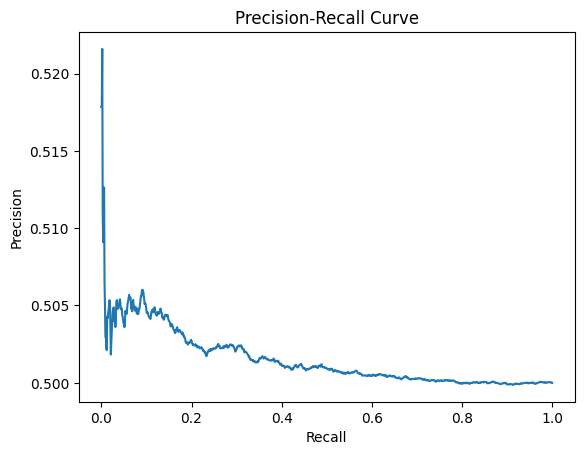

Model Accuracy 0.5008958850628317
FP rate [0.49923846251960463, 0.4989697673547326]
TR rate [0.5010302326452675, 0.5007615374803954]


In [ ]:
import matplotlib.pyplot as plt

print(model.summary)
pr = model.summary.pr.toPandas()
plt.plot(pr['recall'], pr['precision'])
plt.ylabel('Precision')
plt.xlabel('Recall')
plt.title('Precision-Recall Curve')
plt.show()
print("Model Accuracy", model.summary.accuracy)
print("FP rate", model.summary.falsePositiveRateByLabel)
print("TR rate", model.summary.truePositiveRateByLabel)

Total 199756
TruePostive 49747 FalsePostive 50068
TrueNegative 49667 FalseNegative 50274


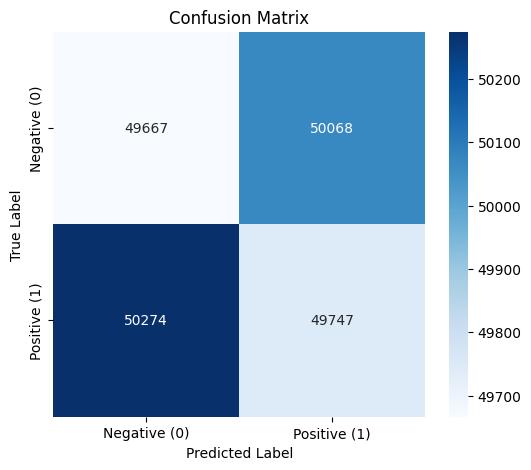

Precision: 0.4984
Recall:    0.4974
F1-score:  0.4979


In [ ]:
import numpy as np
import seaborn as sns

pr = predict_test.toPandas()
TruePositive = 0
FalsePositive = 0
TrueNegative = 0
FalseNegative = 0
Postive = 1.0
Negative = 0.0
pos = 0
Neg = 0

print("Total", len(pr["Survived"]))
for lbl in range(len(pr["Survived"])): # Loop through each prediction
  if pr["prediction"][lbl] == Postive:
    pos += 1
    if pr["prediction"][lbl] == pr["Survived"][lbl]:
      TruePositive += 1
    else:
      FalsePositive += 1
  if pr["prediction"][lbl] == Negative:
    Neg += 1
    if pr["prediction"][lbl] == pr["Survived"][lbl]:
      TrueNegative += 1
    else:
      FalseNegative += 1
print("TruePostive", TruePositive, "FalsePostive", FalsePositive)
print("TrueNegative", TrueNegative, "FalseNegative", FalseNegative)

TN = TrueNegative
FP = FalsePositive
FN = FalseNegative
TP = TruePositive
conf_matrix = np.array([[TN, FP],
                        [FN, TP]])
labels = ["Negative (0)", "Positive (1)"]

plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap="Blues",
            xticklabels=labels, yticklabels=labels)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

precision = TP / (TP + FP) if (TP + FP) > 0 else 0
recall = TP / (TP + FN) if (TP + FN) > 0 else 0
f1_score = 2 * (precision * recall) / (precision + recall) if (precision + recall) > 0 else 0

print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1_score:.4f}")